# Computer Vision — Part 4 · Practical Notebook
## STUDENT VERSION — fill in every `TODO`

**Companion lab for the lecture on segmentation.**

---

This is a **library-first, practical lab** focused on real-world workflows. The stack:

- **`torchvision.models.detection`** — pretrained Mask R-CNN.
- **`torchvision.models.segmentation`** — pretrained DeepLabV3.
- **`segmentation_models_pytorch`** (smp) — U-Net with 500+ pretrained backbones.
- **`torchvision.datasets.OxfordIIITPet`** — built-in segmentation dataset.

### Sections
- §1 Setup
- §6 **Mask R-CNN** — load, infer, filter (TODOs 6.1, 6.2)
- §7 **DeepLabV3** — load, infer, analyze, mask backgrounds (TODOs 7.1, 7.2)
- §9 **U-Net via `smp`** — load, swap backbones, fine-tune, train from scratch (TODOs 9.1, 9.2)
- §10 Loss functions & evaluation metrics

> **How to run:** Google Colab with a GPU (`Runtime → Change runtime type → GPU`) is strongly recommended for §9.


## 1 · Setup & device

The new addition vs. the lecture's setup: `segmentation_models_pytorch` and the torchvision Pets dataset.


In [1]:
# Uncomment on a fresh environment:
# !pip install -q segmentation_models_pytorch

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch device       :", device)
print("torchvision version  :", torchvision.__version__)
print("smp version          :", smp.__version__)


d:\anaconda\envs\cv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device       : cuda
torchvision version  : 0.27.0+cu130
smp version          : 0.5.0


## 6 · Instance segmentation with Mask R-CNN

> *Lecture recap:* Mask R-CNN extends Faster R-CNN with a parallel **mask head** that predicts a per-RoI binary mask alongside the class and box. The key trick is **RoI Align** (bilinear interpolation instead of RoI Pool's quantization), which preserves sub-pixel precision — good for ~+3 mAP in the original paper.

In practice you load it, you don't build it.


In [2]:
# Pretrained Mask R-CNN with ResNet-50 + FPN, COCO weights. ~180 MB.
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights,
)

weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
mask_rcnn = maskrcnn_resnet50_fpn(weights=weights).to(device).eval()
COCO_CATEGORIES = weights.meta["categories"]    # 91 classes (index 0 = background)

print(f"Mask R-CNN loaded with {len(COCO_CATEGORIES)} COCO categories")
print("Examples:", COCO_CATEGORIES[1:6], "...")


Mask R-CNN loaded with 91 COCO categories
Examples: ['person', 'bicycle', 'car', 'motorcycle', 'airplane'] ...


In [3]:
import urllib.request
from PIL import Image
from torchvision import transforms
import os

# Multiple reliable alternatives with multiple objects — try in order
CANDIDATES = [
    "https://raw.githubusercontent.com/ultralytics/assets/main/im/image8.jpg",   # street scene
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",  # bus + people
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",  # people
]

IMG_PATH = "sample.jpg"

for url in CANDIDATES:
    try:
        urllib.request.urlretrieve(url, IMG_PATH)
        img_test = Image.open(IMG_PATH).convert("RGB")
        print(f"✓ Downloaded from: {url}")
        print(f"  Image size: {img_test.size}")
        break
    except Exception as e:
        print(f"✗ Failed: {url} — {e}")

img_pil = Image.open(IMG_PATH).convert("RGB")
img_t   = transforms.functional.to_tensor(img_pil).to(device)

with torch.no_grad():
    output = mask_rcnn([img_t])[0]

print("Output keys :", list(output.keys()))
print("# detections:", len(output['scores']))
print("masks shape :", tuple(output['masks'].shape))
print("top 5 scores:", output['scores'][:5].cpu().numpy().round(3))

✗ Failed: https://raw.githubusercontent.com/ultralytics/assets/main/im/image8.jpg — HTTP Error 404: Not Found
✓ Downloaded from: https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg
  Image size: (810, 1080)
Output keys : ['boxes', 'labels', 'scores', 'masks']
# detections: 32
masks shape : (32, 1, 1080, 810)
top 5 scores: [0.998 0.998 0.995 0.995 0.976]


Visualize the raw output. Notice how many low-confidence detections come back — by default, every score above ~0.05.


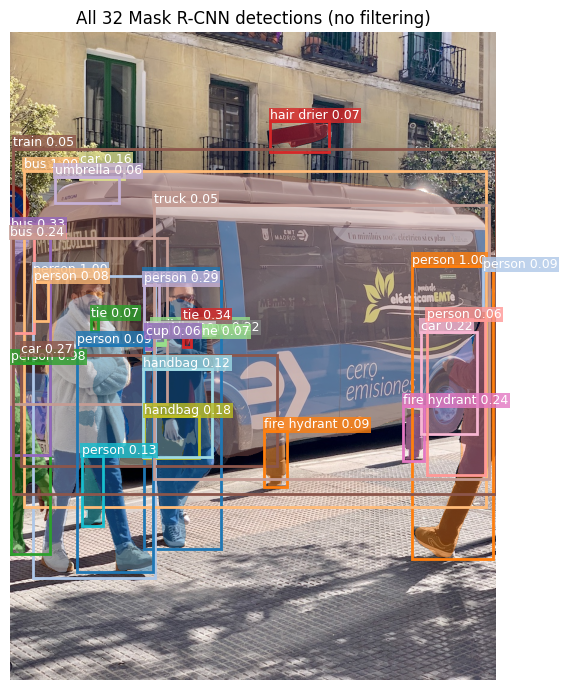

In [4]:
def visualize_masks(img_pil, boxes, masks, labels, scores, title=""):
    """Overlay color-coded masks + boxes on an image."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img_pil)
    H, W = img_pil.size[1], img_pil.size[0]
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    cmap = plt.get_cmap("tab20")
    for i, (m, lbl, sc) in enumerate(zip(masks, labels, scores)):
        color = cmap(i % 20)
        m_np = m[0].cpu().numpy() if isinstance(m, torch.Tensor) else m
        overlay[m_np > 0.5] = (*color[:3], 0.45)
        cls_name = COCO_CATEGORIES[lbl]
        x1, y1, x2, y2 = boxes[i].cpu().numpy() if isinstance(boxes, torch.Tensor) else boxes[i]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor=color, linewidth=2))
        ax.text(x1, y1 - 4, f"{cls_name} {sc:.2f}",
                color="white", fontsize=9,
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))
    ax.imshow(overlay)
    ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()

# Show ALL detections, however weak.
visualize_masks(
    img_pil,
    boxes=output['boxes'],
    masks=output['masks'],
    labels=output['labels'].cpu().numpy(),
    scores=output['scores'].cpu().numpy(),
    title=f"All {len(output['scores'])} Mask R-CNN detections (no filtering)",
)


### TODO 6.1 — Score-threshold filtering

The raw output above contains many low-confidence detections that are **not what you ship**. The first thing every production pipeline does is filter by score. Filter `output` to keep only detections with `score >= 0.7` and re-visualize. This is *the* single most common post-processing step.


5 detections kept (score >= 0.7)


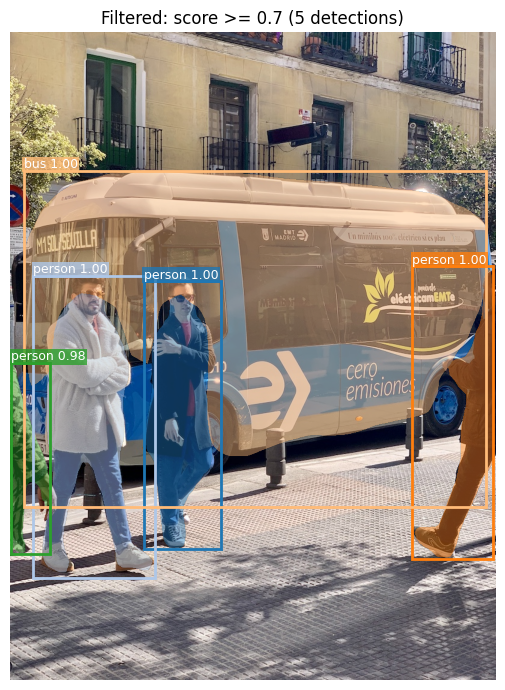

In [5]:
# TODO 6.1 -- Score-threshold filtering.
#
# Filter `output` to keep only detections with score >= 0.7, then call
# visualize_masks again with the filtered tensors. This is the single
# most common post-processing step in every production Mask R-CNN
# pipeline.
#
# Hint: build a boolean tensor `keep = output['scores'] >= 0.7`, then
# use dictionary comprehension to subset every value:
#     filtered = {k: v[keep] for k, v in output.items()}
#
# Pass filtered['boxes'], filtered['masks'], filtered['labels'], and
# filtered['scores'] to visualize_masks. Use a title like
# 'Filtered: score >= 0.7 (N detections)' (compute N from keep.sum()).

SCORE_THRESH = 0.7
# TODO: build `keep` and `filtered`, print how many survived, and
#       call visualize_masks(...).

keep = output['scores'] >= SCORE_THRESH
filtered = {k: v[keep] for k, v in output.items()}

print(f"{keep.sum().item()} detections kept (score >= {SCORE_THRESH})")

visualize_masks(
    img_pil,
    boxes=filtered['boxes'],
    masks=filtered['masks'],
    labels=filtered['labels'].cpu().numpy(),
    scores=filtered['scores'].cpu().numpy(),
    title=f"Filtered: score >= {SCORE_THRESH} ({keep.sum().item()} detections)",
)


### TODO 6.2 — Single-class filtering

Most real applications care about **one or two specific classes**, not all 91 COCO categories. Filter `output` to keep only **`person`** detections (with score ≥ 0.5) and re-visualize. Hint: `COCO_CATEGORIES.index('person')` gives you the class index.


Person detections kept: 4


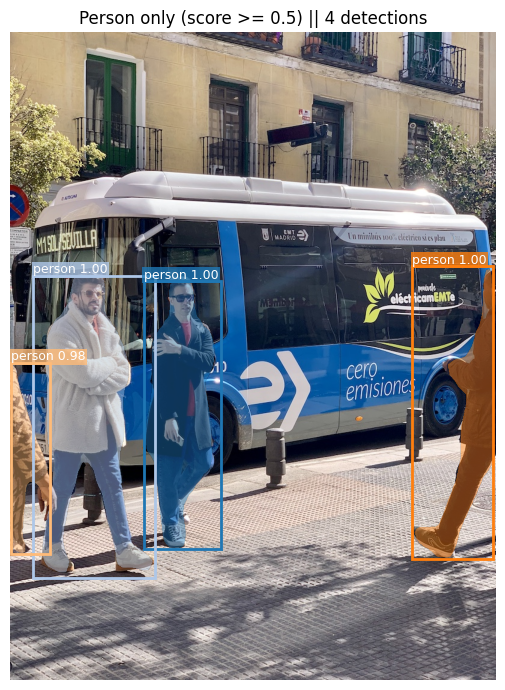

In [6]:
# TODO 6.2 -- Single-class filtering.
#
# Most apps care about ONE class, not all 91 COCO classes. Filter
# `output` to keep only PERSON detections with score >= 0.5, then
# re-visualize.
#
# Hints:
#   PERSON_IDX = COCO_CATEGORIES.index('person')
#   keep = (output['labels'] == PERSON_IDX) & (output['scores'] >= 0.5)
#   people_only = {k: v[keep] for k, v in output.items()}

PERSON_IDX = ...    # TODO: look up the class index
keep = ...          # TODO: boolean mask combining class AND score filter
people_only = ...   # TODO: subset every key of output by keep

# TODO: print how many were kept, then call visualize_masks(...) with the
# people_only fields.

PERSON_IDX = COCO_CATEGORIES.index('person')

keep = (output['labels'] == PERSON_IDX) & (output['scores'] >= 0.5)
people_only = {k: v[keep] for k, v in output.items()}

print(f"Person detections kept: {keep.sum().item()}")

visualize_masks(
    img_pil,
    boxes=people_only['boxes'],
    masks=people_only['masks'],
    labels=people_only['labels'].cpu().numpy(),
    scores=people_only['scores'].cpu().numpy(),
    title=f"Person only (score >= 0.5) || {keep.sum().item()} detections",
)


## 7 · Semantic segmentation with DeepLabV3

> *Lecture recap:* DeepLabV3 uses **atrous (dilated) convolutions** in the backbone to expand the receptive field without losing resolution. The output is a single tensor `(N, num_classes, H, W)` — every pixel gets a class probability. No instances, no boxes — just region labels.

Same library pattern as Mask R-CNN: load weights, run, parse.


In [7]:
from torchvision.models.segmentation import (
    deeplabv3_resnet50, DeepLabV3_ResNet50_Weights,
)

weights = DeepLabV3_ResNet50_Weights.DEFAULT
deeplab = deeplabv3_resnet50(weights=weights).to(device).eval()

# DeepLabV3 ships trained on Pascal VOC + COCO -- 21 classes.
VOC_CLASSES = weights.meta['categories']
print(f"DeepLabV3 loaded with {len(VOC_CLASSES)} classes")
print("All classes:", VOC_CLASSES)


DeepLabV3 loaded with 21 classes
All classes: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [8]:
# Run on the same image. DeepLabV3 wants a normalized input.
preprocess = weights.transforms()
x = preprocess(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    out = deeplab(x)['out']                    # (1, 21, H, W) logits
pred_classes = out.argmax(dim=1).squeeze(0).cpu().numpy()   # (H, W) ints in [0, 20]
print("pred_classes shape:", pred_classes.shape)
print("unique classes in this image:",
      [VOC_CLASSES[c] for c in np.unique(pred_classes)])


pred_classes shape: (693, 520)
unique classes in this image: ['__background__', 'bus', 'person']


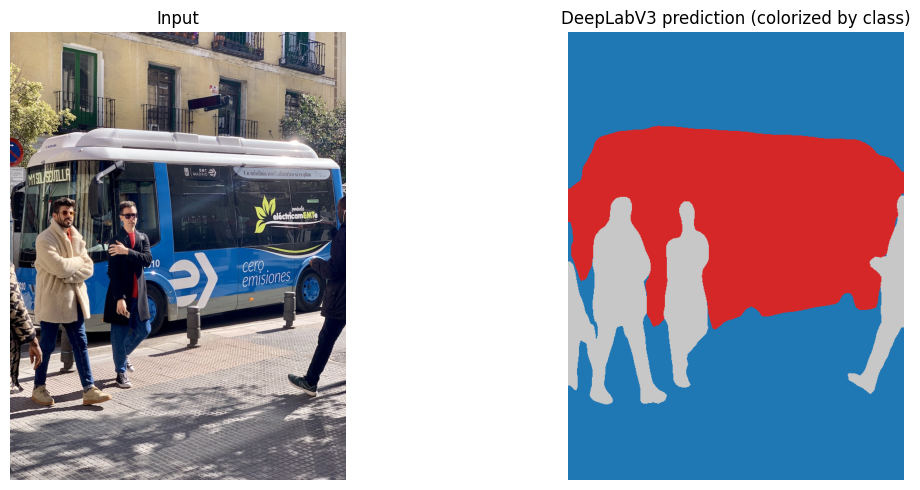

In [9]:
# Colorize the segmentation map.
def colorize_segmentation(seg, n_classes):
    cmap = plt.get_cmap("tab20", n_classes)
    rgba = cmap(seg / max(n_classes - 1, 1))
    return (rgba[..., :3] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img_pil); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(colorize_segmentation(pred_classes, len(VOC_CLASSES)))
axes[1].set_title("DeepLabV3 prediction (colorized by class)"); axes[1].axis("off")
plt.tight_layout(); plt.show()


### TODO 7.1 — Pixel-coverage breakdown

Compute the **percentage of pixels assigned to each class** in `pred_classes` above. Sort the classes by frequency and print the top 5. This is the preprocessing step behind real downstream questions like "how much road is in this image?" or "what fraction is sky?".


In [10]:
# TODO 7.1 -- Pixel-coverage breakdown of the DeepLabV3 prediction.
#
# Compute what FRACTION of pixels was assigned to each class in
# `pred_classes`, sort by descending frequency, and print the top 5
# along with their VOC_CLASSES names.
#
# Useful tools:
#   np.bincount(arr.ravel(), minlength=len(VOC_CLASSES))
#     -> counts of integer class IDs, padded to # classes.
#   np.argsort(-x)[:5]
#     -> indices of top 5 values (negate to sort DESCENDING).

counts = np.bincount(pred_classes.ravel(), minlength=len(VOC_CLASSES))        # TODO
total = pred_classes.size         # TODO
fractions = counts / total     # TODO

order = np.argsort(-fractions)[:5]         # TODO: indices of the top 5 by fraction

# --- given: pretty-print ---
print("Top 5 classes by pixel coverage:")
for idx in order:
    if fractions[idx] > 0:
        bar = "█" * int(fractions[idx] * 30)
        print(f"  {VOC_CLASSES[idx]:15s} : {fractions[idx]:6.1%}  {bar}")


Top 5 classes by pixel coverage:
  __background__  :  56.4%  ████████████████
  bus             :  30.8%  █████████
  person          :  12.7%  ███


### TODO 7.2 — Background masking (the portrait-mode feature)

Combine the semantic mask with the original image to **keep only the `person` pixels and blank everything else**. This is the exact recipe behind portrait-mode background blur on phones and video-call background removal. Display the input alongside the masked output.

Hint: `pred_classes == VOC_CLASSES.index('person')` gives you a `(H, W)` boolean mask. Multiply it (broadcast over channels) with the original image tensor.


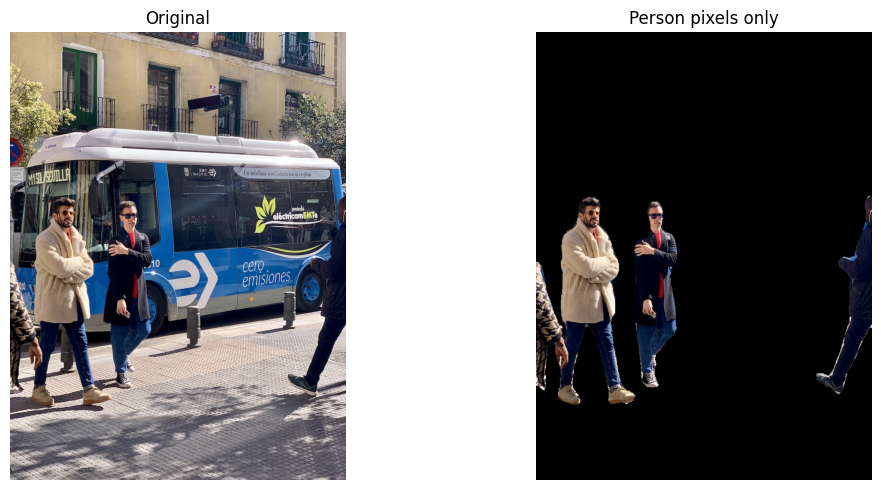

Person pixels: 12.8% of the image


In [11]:
# TODO 7.2 -- Background masking (the portrait-mode feature).
#
# Build a binary mask of `person` pixels and multiply it into the
# original image so only person pixels remain. Display the input and
# the masked output side by side.
#
# Steps:
#   1. PERSON_VOC_IDX = VOC_CLASSES.index('person')
#   2. The prediction is at the model's post-preprocess size (smaller
#      than the original image). Resize it back with NEAREST neighbour
#      (NOT bilinear -- class IDs are labels, not intensities):
#         mask_small = torch.from_numpy(pred_classes).unsqueeze(0).unsqueeze(0).float()
#         mask_full  = F.interpolate(mask_small, size=img_pil.size[::-1], mode='nearest')
#         mask_full  = mask_full.squeeze().long().numpy()
#   3. person_mask = (mask_full == PERSON_VOC_IDX)         # (H, W) boolean
#   4. img_np = np.array(img_pil)                          # (H, W, 3)
#      masked = img_np * person_mask[..., None]            # broadcast over channels
#   5. Display img_pil and masked side by side with plt.subplots(1, 2).

import torch.nn.functional as F
PERSON_VOC_IDX = VOC_CLASSES.index('person')

# TODO: build mask_full (resized), person_mask (boolean), masked (multiplied image)
mask_small = torch.from_numpy(pred_classes).unsqueeze(0).unsqueeze(0).float()
mask_full  = F.interpolate(mask_small, size=img_pil.size[::-1], mode='nearest')
mask_full  = mask_full.squeeze().long().numpy()

person_mask = (mask_full == PERSON_VOC_IDX)

img_np  = np.array(img_pil)
masked  = img_np * person_mask[..., None]

# TODO: side-by-side display + print the person-pixel fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_pil);  axes[0].set_title("Original");          axes[0].axis("off")
axes[1].imshow(masked);   axes[1].set_title("Person pixels only"); axes[1].axis("off")
plt.tight_layout(); plt.show()

person_frac = person_mask.mean()
print(f"Person pixels: {person_frac:.1%} of the image")


## 9 · U-Net with `segmentation_models_pytorch`

This is the **heart of the lab**. In production you don't implement U-Net from scratch. You import `smp` and pick a backbone. Then you **fine-tune** it on your data. We'll do exactly that — load a pretrained U-Net, fine-tune it on the **Oxford-IIIT Pets** dataset (cats and dogs with pixel-level masks built into torchvision), and measure how it performs.

> *Lecture recap:* U-Net has an **encoder** (downsampling, capturing context) and a **decoder** (upsampling, restoring resolution), connected by **skip connections** that let the decoder use the encoder's fine spatial detail. The decoder's job is to combine *what* (from the deep encoder) with *where* (from the shallow skips).


### 9.0 · One-line model construction

Building a U-Net with `smp` is one constructor call. Three things to pick:
1. **`encoder_name`** — which backbone? Options span from `mobilenet_v2` (tiny, ~6M params, runs on phones) through `resnet34`/`resnet50` (workhorse defaults) to `efficientnet-b7` (huge, accurate). 500+ options available — pick by your speed/accuracy budget.
2. **`encoder_weights`** — `"imagenet"` (recommended: pretrained features transfer beautifully to almost any segmentation task) or `None` (random init, only use if you have millions of labelled images).
3. **`classes`** — output channels. `1` for binary segmentation (pet vs background), `21` for Pascal VOC, etc.


In [12]:
# A binary U-Net for the pet-vs-background task we're about to do.
unet = smp.Unet(
    encoder_name="resnet34",        # the workhorse backbone
    encoder_weights="imagenet",     # transfer learning from ImageNet
    in_channels=3,                  # RGB input
    classes=1,                      # binary: 1 channel of logits
).to(device)

print("params:", f"{sum(p.numel() for p in unet.parameters()):,}")
# Sanity-check shape
x = torch.randn(2, 3, 256, 256, device=device)
print("forward shape:", tuple(unet(x).shape), " (expected (2, 1, 256, 256))")


params: 24,436,369
forward shape: (2, 1, 256, 256)  (expected (2, 1, 256, 256))


### TODO 9.1 — Swap the backbone, count parameters

The whole point of `smp` is **one-line backbone swap**. Build the same `smp.Unet` with each of these encoders and print the parameter count for each:

- `"mobilenet_v2"` — what you'd ship on a phone.
- `"resnet34"` — the workhorse default.
- `"efficientnet-b0"` — efficient mid-size.
- `"resnet50"` — heavier, more accurate.

All same `in_channels=3`, `classes=1`, `encoder_weights="imagenet"`. Comment on what this gives you in real work.


In [13]:
# TODO 9.1 -- Swap the backbone, count parameters.
#
# For each encoder string in `encoders`, build smp.Unet with:
#   encoder_name=enc, encoder_weights='imagenet',
#   in_channels=3, classes=1
# Sum the parameters and print the totals in a table.
#
# Note how much smaller mobilenet_v2 is than resnet50 -- that's the
# point of having one-line backbone swap.

encoders = ["mobilenet_v2", "resnet34", "efficientnet-b0", "resnet50"]
print(f"{'encoder':<22s} {'params':>15s}")
print("-" * 40)
for enc in encoders:
    # TODO: build the model and count parameters; print a row
    model = smp.Unet(
        encoder_name=enc,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    )
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{enc:<22s} {n_params:>15,}")

# TODO (written): what does one-line backbone swap give you in real work?
# Your answer:
# one line backbone swap made me trade the accuracy with speed/size of model.


encoder                         params
----------------------------------------
mobilenet_v2                 6,628,945
resnet34                    24,436,369
efficientnet-b0              6,251,469
resnet50                    32,521,105


### 9.2 · Load the Oxford-IIIT Pets dataset

We use `torchvision.datasets.OxfordIIITPet` with `target_types="segmentation"` — this gives us 7,400 images of cats and dogs, each with a **trimap mask** (3 classes: pet, border, background). We convert it to a *binary* mask (pet vs not-pet) for simplicity.

First time runs the download (~800 MB) — be patient. Subsequent runs are instant.


In [14]:
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

IMG_SIZE = 128       # small for fast lab-pace training
DATA_ROOT = "./pet_data"

# Match preprocessing to ImageNet pretraining (so the pretrained encoder works)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

def mask_tf(mask_pil):
    # Trimap: 1 = pet, 2 = background, 3 = border. We collapse to BINARY:
    # pet=1 -> foreground; anything else -> background.
    m = mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    arr = np.array(m)
    binary = (arr == 1).astype(np.float32)   # 1.0 where pet, else 0.0
    return torch.from_numpy(binary).unsqueeze(0)    # (1, H, W)

train_ds = OxfordIIITPet(root=DATA_ROOT, split="trainval",
                         target_types="segmentation", download=True,
                         transform=img_tf, target_transform=mask_tf)
val_ds   = OxfordIIITPet(root=DATA_ROOT, split="test",
                         target_types="segmentation", download=True,
                         transform=img_tf, target_transform=mask_tf)

# Small subsets so the lab runs in minutes -- in real fine-tuning you'd use everything.
from torch.utils.data import Subset
import random
random.seed(0)
train_idx = random.sample(range(len(train_ds)), 500)
val_idx   = random.sample(range(len(val_ds)),   200)
train_subset = Subset(train_ds, train_idx)
val_subset   = Subset(val_ds,   val_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=16, shuffle=False, num_workers=2)

print(f"training subset : {len(train_subset)}")
print(f"validation subset: {len(val_subset)}")

# Peek at one sample
img, mask = train_subset[0]
print(f"sample image: {tuple(img.shape)}, mask: {tuple(mask.shape)}, "
      f"mask values: {torch.unique(mask).tolist()}")


training subset : 500
validation subset: 200
sample image: (3, 128, 128), mask: (1, 128, 128), mask values: [0.0, 1.0]


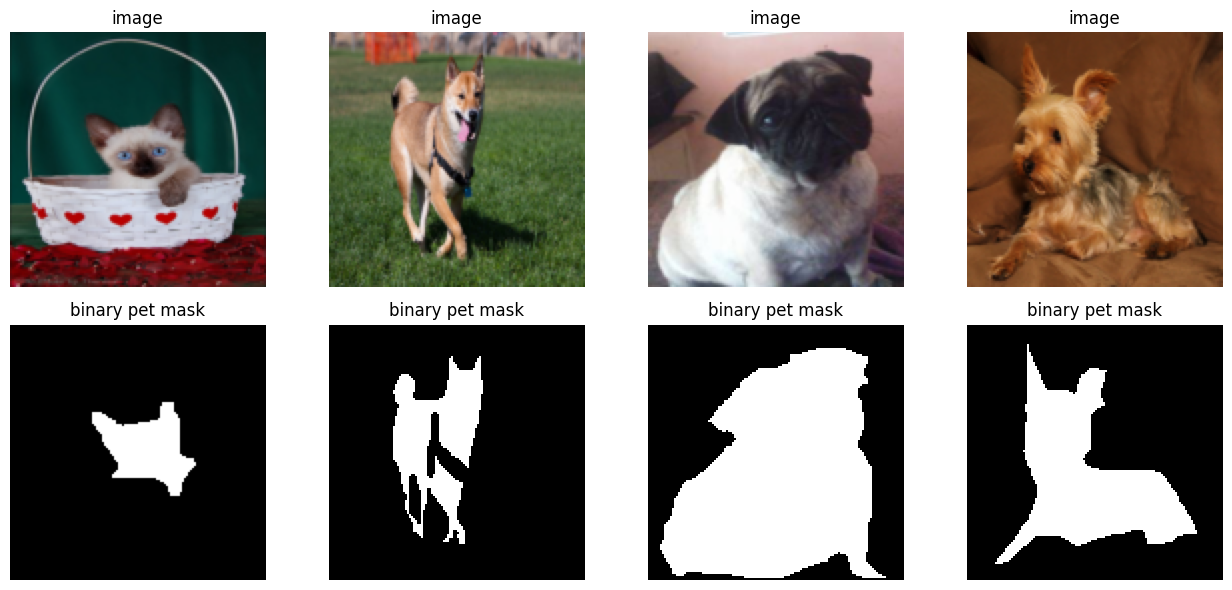

In [15]:
# Visualize a few training pairs.
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i in range(4):
    img, mask = train_subset[i]
    # un-normalize for display
    img_disp = img.permute(1, 2, 0).numpy() * imagenet_std + imagenet_mean
    img_disp = np.clip(img_disp, 0, 1)
    axes[0, i].imshow(img_disp);                axes[0, i].axis("off")
    axes[0, i].set_title("image")
    axes[1, i].imshow(mask.squeeze(), cmap="gray"); axes[1, i].axis("off")
    axes[1, i].set_title("binary pet mask")
plt.tight_layout(); plt.show()


### 9.3 · Fine-tune with frozen encoder

Two common ways to adapt a pretrained `smp.Unet` to your data:

1. **Fine-tune with frozen encoder** — freeze the ImageNet-pretrained encoder, train only the decoder. **Fast**, doesn't risk damaging good low-level features, works great when your dataset is small. This is the default first thing to try.
2. **Full fine-tune** — unfreeze everything, train with a low learning rate. Slower, needs more data, can squeeze a bit more performance.

We do the frozen-encoder variant first because it's what you'd do first in a real project.


In [ ]:
# Build a fresh model and freeze its encoder.
unet_frozen = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3, classes=1,
).to(device)

print(device)
print(next(unet_frozen.parameters()).device)

# Freeze every parameter in the encoder. The decoder + segmentation_head stay trainable.
for p in unet_frozen.encoder.parameters():
    p.requires_grad = False

n_trainable = sum(p.numel() for p in unet_frozen.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in unet_frozen.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,} "
      f"({100*n_trainable/n_total:.1f}%)")

# Standard segmentation training setup: Dice + BCE loss (combine to get
# the benefits of both), Adam optimizer on the trainable params only.
loss_dice = smp.losses.DiceLoss(mode="binary")
loss_bce  = smp.losses.SoftBCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    [p for p in unet_frozen.parameters() if p.requires_grad],
    lr=1e-3,
)

def compute_iou(logits, masks):
    """Compute mean IoU over a batch using smp.metrics."""
    preds = (logits.sigmoid() > 0.5).long()
    tp, fp, fn, tn = smp.metrics.get_stats(preds, masks.long(), mode="binary")
    return smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()

EPOCHS = 3
for epoch in range(1, EPOCHS + 1):
    unet_frozen.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = unet_frozen(imgs)
        loss = loss_dice(logits, masks) + loss_bce(logits, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    unet_frozen.eval()
    val_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = unet_frozen(imgs)
            val_iou += compute_iou(logits, masks)
    val_iou /= len(val_loader)
    print(f"epoch {epoch}/{EPOCHS}  train loss {train_loss:.4f}  val IoU {val_iou:.3f}")


cuda
cuda:0
Trainable params: 3,151,697 / 24,436,369 (12.9%)


In [ ]:
# Visualize the fine-tuned predictions on a few validation images.
unet_frozen.eval()
with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs = imgs.to(device)
    preds = unet_frozen(imgs).sigmoid().cpu().numpy()    # (B, 1, H, W)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for i in range(4):
    img_disp = imgs[i].cpu().permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp * imagenet_std + imagenet_mean, 0, 1)
    axes[0, i].imshow(img_disp);              axes[0, i].axis("off"); axes[0, i].set_title("image")
    axes[1, i].imshow(masks[i].squeeze(), cmap="gray");      axes[1, i].axis("off"); axes[1, i].set_title("ground truth")
    axes[2, i].imshow(preds[i, 0] > 0.5, cmap="gray");        axes[2, i].axis("off"); axes[2, i].set_title("predicted")
plt.tight_layout(); plt.show()


### TODO 9.2 — Train the U-Net *from scratch* (random init)

Now do the **opposite** of fine-tuning: build a new `smp.Unet` with **`encoder_weights=None`** (random init — no ImageNet pretraining) and train it for the same 3 epochs on the same data. Track val IoU.

**Predict before you run it**: how do you expect the from-scratch IoU to compare to the fine-tuned one above? Why?

(Hint: nothing changes vs. the training loop above except how you construct the model and you can skip the freezing step — there's no pretraining to preserve.)


In [ ]:
# TODO 9.2 -- Train the U-Net from scratch (random init).
#
# Construct unet_scratch the same way as unet_frozen ABOVE except set:
#   encoder_weights=None       (no ImageNet pretraining, random init)
# and you don't need to freeze anything (there's no pretrained encoder
# to preserve).
#
# Use the SAME loss combination (loss_dice + loss_bce), the SAME EPOCHS
# value, the SAME train_loader / val_loader / compute_iou. The only
# difference is the model object and (implicitly) the optimizer should
# now optimize ALL parameters of unet_scratch.
#
# Before you run it: predict what will happen relative to the frozen-
# encoder run. Will from-scratch IoU be higher or lower? Why?
# Your prediction:
# from scratch iou will be lower than the finetuned run.

unet_scratch = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,          # <-- key difference: random init
        in_channels=3,
        classes=1,
    ).to(device)    # TODO: smp.Unet with encoder_weights=None

optimizer_s = torch.optim.Adam(unet_scratch.parameters(), lr=1e-3)      # TODO: Adam over all parameters of unet_scratch

for epoch in range(1, EPOCHS + 1):
    # TODO: training loop (same shape as the frozen-encoder loop above)
    #   - set unet_scratch.train()
    #   - loop over train_loader; compute Dice + BCE loss; step the optimizer
    #   - set unet_scratch.eval()
    #   - loop over val_loader with torch.no_grad(); accumulate compute_iou
    #   - print 'FROM SCRATCH epoch X/Y  train_loss Z  val IoU W'
    unet_scratch.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = unet_scratch(imgs)
        loss = loss_dice(logits, masks) + loss_bce(logits, masks)
        optimizer_s.zero_grad(); loss.backward(); optimizer_s.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    unet_scratch.eval()
    val_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = unet_scratch(imgs)
            val_iou += compute_iou(logits, masks)
    val_iou /= len(val_loader)
    print(f"FROM SCRATCH epoch {epoch}/{EPOCHS}  train loss {train_loss:.4f}  val IoU {val_iou:.3f}")

# TODO (written): after running, was your prediction right? Why does
# this happen?
# Your answer: yes the prediction is right. from scratch score lower because random weight initialization need many more epochs to learn usefull features. the pretrained model already knows how to detect shapes and textures.


### 10.1 · Which loss for segmentation?

Segmentation is **pixel-wise classification with severe class imbalance**. In a pet image, ~70% of pixels are background and ~30% are pet. A naive cross-entropy loss happily learns to predict background everywhere and gets 70% accuracy. That's why segmentation papers use **region-overlap losses** like Dice or Jaccard, often combined with cross-entropy for stable gradients.

`smp.losses` ships every loss you need. The five worth knowing:

| Loss | When to reach for it |
|---|---|
| `DiceLoss` | Default for binary / multi-class segmentation. Optimizes IoU-like overlap. Heavily class-imbalance robust. |
| `SoftBCEWithLogitsLoss` | Binary CE with optional label smoothing. Use *alongside* Dice for smoother gradients. |
| `FocalLoss` | When even Dice struggles with extreme imbalance (e.g., tiny medical lesions). Down-weights easy examples. |
| `JaccardLoss` | Same idea as Dice but optimizes the IoU formula directly. Mostly Dice's twin. |
| `TverskyLoss` | Like Dice but tunable: trade false positives vs false negatives via two coefficients. |


In [ ]:
# Show that Dice and BCE see the same prediction very differently.
# 1) A near-perfect prediction
y = torch.zeros(1, 1, 64, 64); y[:, :, 16:48, 16:48] = 1.0     # a square ground-truth
logits_good = (y * 5 - 2.5)        # high logit where target=1, low where target=0
# 2) A trivial 'all background' prediction
logits_bg   = torch.full_like(y, -3.0)

dice = smp.losses.DiceLoss(mode="binary")
bce  = smp.losses.SoftBCEWithLogitsLoss()

print(f"{'prediction':22s} | {'Dice':>8s} | {'BCE':>8s}")
print("-" * 46)
print(f"{'near-perfect':22s} | {dice(logits_good, y):>8.3f} | {bce(logits_good, y):>8.3f}")
print(f"{'all background':22s} | {dice(logits_bg,   y):>8.3f} | {bce(logits_bg,   y):>8.3f}")

# Notice: BCE only mildly punishes the 'all background' prediction (3/4 of
# pixels are correct, after all). Dice punishes it hard, because IoU with
# the ground-truth square is essentially zero. THAT is why segmentation
# papers default to Dice.


### 10.2 · Which metric for evaluation?

**Don't use pixel accuracy.** It's high by default for the reason the loss section just showed: most pixels are background, so a trivial predictor scores well. Use:

- **IoU** (Intersection over Union, aka Jaccard) — *the* standard segmentation metric. Reported as `mIoU` (mean over classes) in papers.
- **Dice** coefficient — equivalent to IoU rank-wise; common in medical imaging.
- **Pixel accuracy** — only as a sanity-check, never as the primary metric.

`smp.metrics` ships these correctly. Use `get_stats` to count TP/FP/FN/TN, then call any of `iou_score`, `f1_score`, `accuracy`, etc.
